In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── utils.py
import os, csv
import numpy as np
from scipy.linalg import svd as scipy_svd
from scipy.optimize import curve_fit

def _bipartite_matrix(statevector, n, cut):
    psi = np.asarray(statevector, dtype=complex).ravel()
    return psi.reshape(2**cut, 2**(n-cut))

def von_neumann_entropy(statevector, n, cut):
    sv = scipy_svd(_bipartite_matrix(statevector, n, cut), compute_uv=False)
    lam = sv**2; lam = lam[lam > 1e-15]
    return float(-np.sum(lam * np.log2(lam)))

def compute_chi(statevector, n, cut, eps=1e-6):
    sv = scipy_svd(_bipartite_matrix(statevector, n, cut), compute_uv=False)
    return int(np.sum(sv > eps))

def get_schmidt_spectrum(statevector, n, cut):
    sv = scipy_svd(_bipartite_matrix(statevector, n, cut), compute_uv=False)
    return np.sort(sv**2)[::-1]

def truncation_error(statevector, n, cut, chi):
    return float(1.0 - np.sum(get_schmidt_spectrum(statevector, n, cut)[:chi]))

CSV_COLS = ['algorithm','n','step','cut','entropy','chi','trunc_error','runtime_s','instance_id']

def append_csv(row, filepath):
    os.makedirs(os.path.dirname(os.path.abspath(filepath)), exist_ok=True)
    exists = os.path.isfile(filepath)
    with open(filepath, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=CSV_COLS)
        if not exists: w.writeheader()
        w.writerow({k: row.get(k,'') for k in CSV_COLS})

def _log_model(n, a, b):    return a * np.log2(n.astype(float)) + b
def _linear_model(n, c, d): return c * n.astype(float) + d

def _aic(resid, k):
    rss = np.sum(resid**2)
    return len(resid)*np.log(rss/len(resid)) + 2*k if rss > 0 else -np.inf

def classify_simulability(ns, s_max):
    ns, s_max = np.asarray(ns, float), np.asarray(s_max, float)
    try:
        lp,_ = curve_fit(_log_model, ns, s_max, p0=[1.,0.]); al = _aic(s_max-_log_model(ns,*lp),2)
    except: lp=(np.nan,np.nan); al=np.inf
    try:
        cp,_ = curve_fit(_linear_model, ns, s_max, p0=[.5,0.]); ac = _aic(s_max-_linear_model(ns,*cp),2)
    except: cp=(np.nan,np.nan); ac=np.inf
    return ('tractable' if al<=ac else 'hard'), lp, cp, al, ac

print("✅ utils loaded")

✅ utils loaded


In [3]:
# ── grover_experiment.py ──────────────────────────────────────────────────────
import time
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

np.random.seed(42)
os.makedirs('results', exist_ok=True)
os.makedirs('peak_states', exist_ok=True)

def grover_oracle(n, marked):
    qc = QuantumCircuit(n, name='Oracle')
    bits = format(marked, f'0{n}b')
    for i, b in enumerate(reversed(bits)):
        if b == '0': qc.x(i)
    qc.h(n-1); qc.mcx(list(range(n-1)), n-1); qc.h(n-1)
    for i, b in enumerate(reversed(bits)):
        if b == '0': qc.x(i)
    return qc

def grover_diffuser(n):
    qc = QuantumCircuit(n, name='Diffuser')
    qc.h(range(n)); qc.x(range(n))
    qc.h(n-1); qc.mcx(list(range(n-1)), n-1); qc.h(n-1)
    qc.x(range(n)); qc.h(range(n))
    return qc

def run_grover_sweep(qubit_sizes=[4,6,8,10,12,14], csv_file='results/grover_results.csv'):
    for n in qubit_sizes:
        cut = n//2
        N   = 2**n
        marked    = int(np.random.randint(0, N))
        max_iters = int(np.floor(np.pi/4 * np.sqrt(N)))
        print(f"\n[Grover] n={n} | N={N} | marked={marked} | max_iters={max_iters}")

        oracle   = grover_oracle(n, marked)
        diffuser = grover_diffuser(n)

        init = QuantumCircuit(n); init.h(range(n))
        sv   = Statevector.from_label('0'*n).evolve(init)

        peak_S, peak_sv = -1.0, None

        for k in range(1, max_iters+1):
            t0 = time.perf_counter()
            sv = sv.evolve(oracle).evolve(diffuser)
            rt = time.perf_counter() - t0

            data = sv.data
            S    = von_neumann_entropy(data, n, cut)
            chi  = compute_chi(data, n, cut)
            eps  = truncation_error(data, n, cut, chi)

            append_csv(dict(algorithm='grover', n=n, step=k, cut=cut,
                            entropy=round(S,8), chi=chi,
                            trunc_error=round(eps,10), runtime_s=round(rt,6),
                            instance_id=marked), csv_file)

            if S > peak_S: peak_S = S; peak_sv = data.copy()
            print(f"  k={k:4d} | S_vN={S:.4f} | chi={chi:5d} | t={rt*1e3:.1f}ms")

        np.save(f'peak_states/grover_n{n}_peak.npy', peak_sv)
    print(f"\n✅ Grover done → {csv_file}")

QUICK = False

run_grover_sweep(qubit_sizes=[4,6,8] if QUICK else [4,6,8,10,12,14])


[Grover] n=4 | N=16 | marked=6 | max_iters=3
  k=   1 | S_vN=0.4250 | chi=    2 | t=4.1ms
  k=   2 | S_vN=0.2603 | chi=    2 | t=4.1ms
  k=   3 | S_vN=0.1704 | chi=    2 | t=3.9ms

[Grover] n=6 | N=64 | marked=51 | max_iters=6
  k=   1 | S_vN=0.2603 | chi=    2 | t=23.1ms
  k=   2 | S_vN=0.5818 | chi=    2 | t=22.3ms
  k=   3 | S_vN=0.6905 | chi=    2 | t=24.7ms
  k=   4 | S_vN=0.5198 | chi=    2 | t=21.3ms
  k=   5 | S_vN=0.1777 | chi=    2 | t=21.0ms
  k=   6 | S_vN=0.0269 | chi=    2 | t=21.1ms

[Grover] n=8 | N=256 | marked=92 | max_iters=12
  k=   1 | S_vN=0.1031 | chi=    2 | t=54.6ms
  k=   2 | S_vN=0.2942 | chi=    2 | t=59.0ms
  k=   3 | S_vN=0.4988 | chi=    2 | t=55.2ms
  k=   4 | S_vN=0.6739 | chi=    2 | t=53.7ms
  k=   5 | S_vN=0.7912 | chi=    2 | t=52.2ms
  k=   6 | S_vN=0.8337 | chi=    2 | t=52.4ms
  k=   7 | S_vN=0.7958 | chi=    2 | t=49.1ms
  k=   8 | S_vN=0.6825 | chi=    2 | t=47.8ms
  k=   9 | S_vN=0.5101 | chi=    2 | t=55.9ms
  k=  10 | S_vN=0.3062 | chi=    

In [4]:
# ── qaoa_experiment.py (OPTIMIZED) ────────────────────────────────────────────
import time, warnings
import numpy as np
import networkx as nx
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize

# Make sure you run the cell with your utils functions first!
# (von_neumann_entropy, compute_chi, truncation_error, append_csv)

np.random.seed(42)
warnings.filterwarnings('ignore')

def make_graph(n, seed):
    try:
        if n >= 4 and n % 2 == 0:
            return nx.random_regular_graph(3, n, seed=seed)
    except: pass
    return nx.erdos_renyi_graph(n, 0.5, seed=seed)

def build_qaoa_circuit(n, p, gamma, beta, G):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for l in range(p):
        for u,v in G.edges():
            qc.cx(u,v); qc.rz(-gamma[l], v); qc.cx(u,v)
        for i in range(n):
            qc.rx(2*beta[l], i)
    return qc

# 🚀 NEW: Precompute cuts once per graph
def precompute_cuts(n, G):
    cuts = np.zeros(2**n)
    for i in range(2**n):
        bits = [(i >> q) & 1 for q in range(n)]
        cuts[i] = sum(1 for u,v in G.edges() if bits[u] != bits[v])
    return cuts

def optimise(n, p, G, seed=42, restarts=3):
    rng = np.random.default_rng(seed)
    best_p, best_v = None, np.inf

    # Precompute the cut values for this specific graph ONCE
    cuts_array = precompute_cuts(n, G)

    # Fast expectation function using NumPy dot product
    def expectation_fast(params):
        gamma, beta = params[:p], params[p:]
        sv = Statevector(build_qaoa_circuit(n, p, gamma, beta, G)).data
        probs = np.abs(sv)**2
        return -np.dot(probs, cuts_array) # 🚀 Instant calculation

    for _ in range(restarts):
        x0  = np.r_[rng.uniform(0, np.pi, p), rng.uniform(0, np.pi/2, p)]
        # Reduced maxiter to 200 (COBYLA plateaus early anyway)
        res = minimize(expectation_fast, x0,
                       method='COBYLA', options={'maxiter':200,'rhobeg':0.5})
        if res.fun < best_v: best_v = res.fun; best_p = res.x.copy()
    return best_p

def run_qaoa_sweep(qubit_sizes=[6,8,10,12], depths=range(1,7),
                   n_instances=5, csv_file='results/qaoa_results.csv'):
    seeds = [42 + i*17 for i in range(n_instances)]
    for n in qubit_sizes:
        cut = n//2
        for inst_id, seed in enumerate(seeds):
            G = make_graph(n, seed)
            print(f"\n[QAOA] n={n} | inst={inst_id} | edges={G.number_of_edges()}")
            for p in depths:
                params = optimise(n, p, G, seed=seed+p)

                # Final evaluation with optimal parameters
                t0     = time.perf_counter()
                sv     = Statevector(build_qaoa_circuit(n, p, params[:p], params[p:], G)).data
                rt     = time.perf_counter() - t0

                S   = von_neumann_entropy(sv, n, cut)
                chi = compute_chi(sv, n, cut)
                eps = truncation_error(sv, n, cut, chi)

                append_csv(dict(algorithm='qaoa', n=n, step=p, cut=cut,
                                entropy=round(S,8), chi=chi,
                                trunc_error=round(eps,10), runtime_s=round(rt,6),
                                instance_id=inst_id), csv_file)

                # Save raw statevector (comment out if you run out of Colab storage)
                # np.save(f'peak_states/qaoa_n{n}_p{p}_inst{inst_id}_peak.npy', sv)
                print(f"  p={p} | S_vN={S:.4f} | chi={chi:5d} | t={rt*1e3:.1f}ms")
    print(f"\n✅ QAOA done → {csv_file}")

# ── Run ───────────────────────────────────────────────────────────────────────
QUICK = False   # Set to True to do a tiny test run first

run_qaoa_sweep(
    qubit_sizes=[6,8]       if QUICK else [6,8,10,12],
    depths=range(1,4)       if QUICK else range(1,7),
    n_instances=2           if QUICK else 5,
)


[QAOA] n=6 | inst=0 | edges=9
  p=1 | S_vN=1.4320 | chi=    8 | t=1.9ms
  p=2 | S_vN=1.6888 | chi=    8 | t=3.5ms
  p=3 | S_vN=1.7104 | chi=    8 | t=5.5ms
  p=4 | S_vN=1.5986 | chi=    8 | t=7.2ms
  p=5 | S_vN=1.6553 | chi=    8 | t=7.3ms
  p=6 | S_vN=1.5704 | chi=    8 | t=8.5ms

[QAOA] n=6 | inst=1 | edges=9
  p=1 | S_vN=1.4321 | chi=    8 | t=1.9ms
  p=2 | S_vN=1.7448 | chi=    8 | t=3.3ms
  p=3 | S_vN=1.6999 | chi=    8 | t=7.2ms
  p=4 | S_vN=1.8368 | chi=    8 | t=6.0ms
  p=5 | S_vN=1.5962 | chi=    8 | t=7.0ms
  p=6 | S_vN=1.6552 | chi=    8 | t=9.8ms

[QAOA] n=6 | inst=2 | edges=9
  p=1 | S_vN=1.5731 | chi=    8 | t=2.1ms
  p=2 | S_vN=2.1827 | chi=    8 | t=3.1ms
  p=3 | S_vN=2.1797 | chi=    8 | t=5.2ms
  p=4 | S_vN=2.4134 | chi=    8 | t=6.1ms
  p=5 | S_vN=2.1278 | chi=    8 | t=7.6ms
  p=6 | S_vN=2.5862 | chi=    8 | t=13.6ms

[QAOA] n=6 | inst=3 | edges=9
  p=1 | S_vN=1.4322 | chi=    8 | t=2.7ms
  p=2 | S_vN=1.6886 | chi=    8 | t=3.1ms
  p=3 | S_vN=1.7032 | chi=    8 | t

In [5]:
import os
import time
import csv
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.linalg import svd as scipy_svd

# ==============================================================================
# 1. UTILITY FUNCTIONS (Required for logging)
# ==============================================================================

def _bipartite_matrix(statevector, n, cut):
    psi = np.asarray(statevector, dtype=complex).ravel()
    return psi.reshape(2**cut, 2**(n-cut))

def von_neumann_entropy(statevector, n, cut):
    sv = scipy_svd(_bipartite_matrix(statevector, n, cut), compute_uv=False)
    lam = sv**2; lam = lam[lam > 1e-15]
    return float(-np.sum(lam * np.log2(lam)))

def compute_chi(statevector, n, cut, eps=1e-6):
    sv = scipy_svd(_bipartite_matrix(statevector, n, cut), compute_uv=False)
    return int(np.sum(sv > eps))

def get_schmidt_spectrum(statevector, n, cut):
    sv = scipy_svd(_bipartite_matrix(statevector, n, cut), compute_uv=False)
    return np.sort(sv**2)[::-1]

def truncation_error(statevector, n, cut, chi):
    return float(1.0 - np.sum(get_schmidt_spectrum(statevector, n, cut)[:chi]))

def append_csv(row, filepath):
    cols = ['algorithm','n','step','cut','entropy','chi','trunc_error','runtime_s','instance_id']
    os.makedirs(os.path.dirname(os.path.abspath(filepath)), exist_ok=True)
    exists = os.path.isfile(filepath)
    with open(filepath, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=cols)
        if not exists: w.writeheader()
        w.writerow({k: row.get(k,'') for k in cols})


# 2. QUANTUM WALK LOGIC


def shift(qc, coin, pos_qubits):
    qc.x(coin)
    for i in reversed(range(1, len(pos_qubits))):
        qc.mcx([coin] + pos_qubits[:i], pos_qubits[i])
    qc.cx(coin, pos_qubits[0])
    qc.x(coin)
    for i in range(len(pos_qubits) - 1):
        qc.x(pos_qubits[i])
    for i in reversed(range(1, len(pos_qubits))):
        qc.mcx([coin] + pos_qubits[:i], pos_qubits[i])
    for i in range(len(pos_qubits) - 1):
        qc.x(pos_qubits[i])
    qc.cx(coin, pos_qubits[0])

def set_position(qc, index, qubits):
    bits = format(index, f"0{len(qubits)}b")[::-1]
    for i, bit in enumerate(bits):
        if bit == "1":
            qc.x(qubits[i])

# 3. EXPERIMENT EXECUTION (With Data Storing)

N_STEPS = 12
QUBIT_RANGE = [3, 4, 5, 6, 7, 8]
CSV_FILE = 'results/qw_results.csv'

os.makedirs('results', exist_ok=True)
os.makedirs('peak_states', exist_ok=True)

def run_qw_with_logging(n_qubits):
    total_q = 1 + n_qubits
    coin = 0
    pos_qubits = list(range(1, total_q))
    center = (2**n_qubits) // 2

    qc = QuantumCircuit(total_q)
    set_position(qc, center, pos_qubits)

    peak_S, peak_sv = -1.0, None

    for t in range(N_STEPS + 1):
        t0 = time.perf_counter()
        state = Statevector(qc)
        rt = time.perf_counter() - t0

        data = state.data

        # Partition the 1-qubit coin from the position register
        S = von_neumann_entropy(data, total_q, cut=1)
        chi = compute_chi(data, total_q, cut=1)
        eps = truncation_error(data, total_q, cut=1, chi=chi)

        # Store metadata for Plotting
        append_csv(dict(algorithm='qw', n=n_qubits, step=t, cut=1,
                        entropy=round(S, 8), chi=chi,
                        trunc_error=round(eps, 10), runtime_s=round(rt, 6),
                        instance_id=0), CSV_FILE)

        if S > peak_S:
            peak_S = S
            peak_sv = data.copy()

        if t < N_STEPS:
            qc.h(coin)
            shift(qc, coin, pos_qubits)

    np.save(f'peak_states/qw_n{n_qubits}_peak.npy', peak_sv)

# Run Simulation Sweep
print("Starting Quantum Walk Simulation...")
for nq in QUBIT_RANGE:
    print(f"  Simulating QW for n={nq} position qubits...")
    run_qw_with_logging(nq)
print(f"\n✅ Quantum Walk done → {CSV_FILE}")

Starting Quantum Walk Simulation...
  Simulating QW for n=3 position qubits...
  Simulating QW for n=4 position qubits...
  Simulating QW for n=5 position qubits...
  Simulating QW for n=6 position qubits...
  Simulating QW for n=7 position qubits...
  Simulating QW for n=8 position qubits...

✅ Quantum Walk done → results/qw_results.csv


  grover: 196 rows loaded
  qaoa: 120 rows loaded
  qw: 78 rows loaded


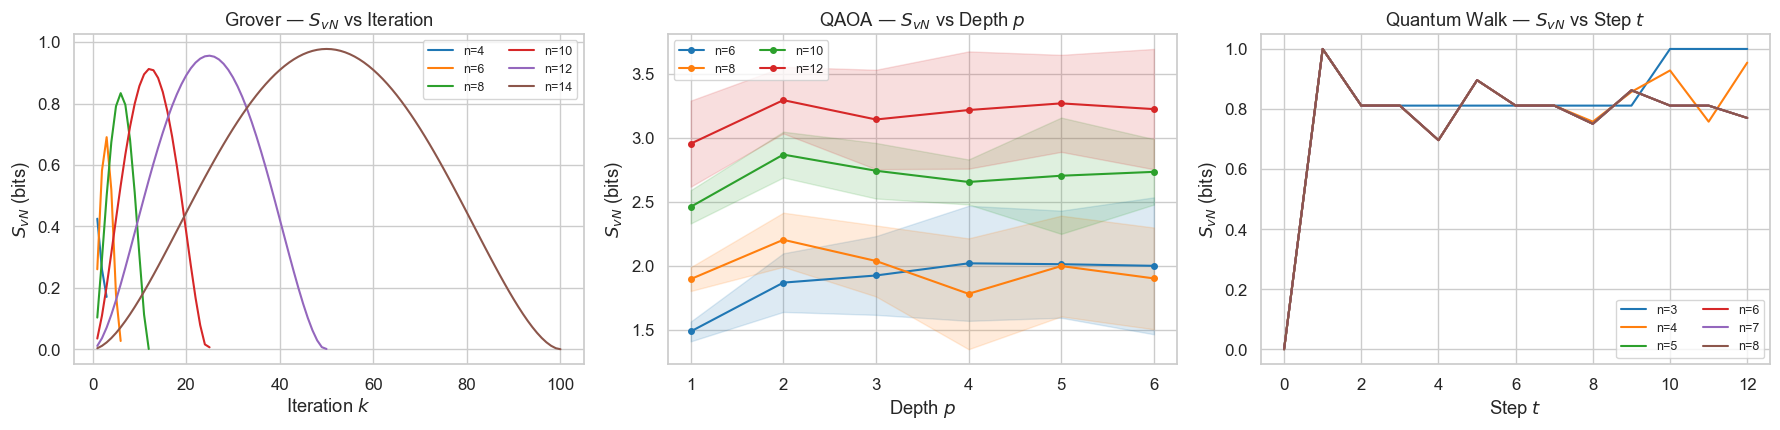

  → figures/fig1_entropy_vs_step.png


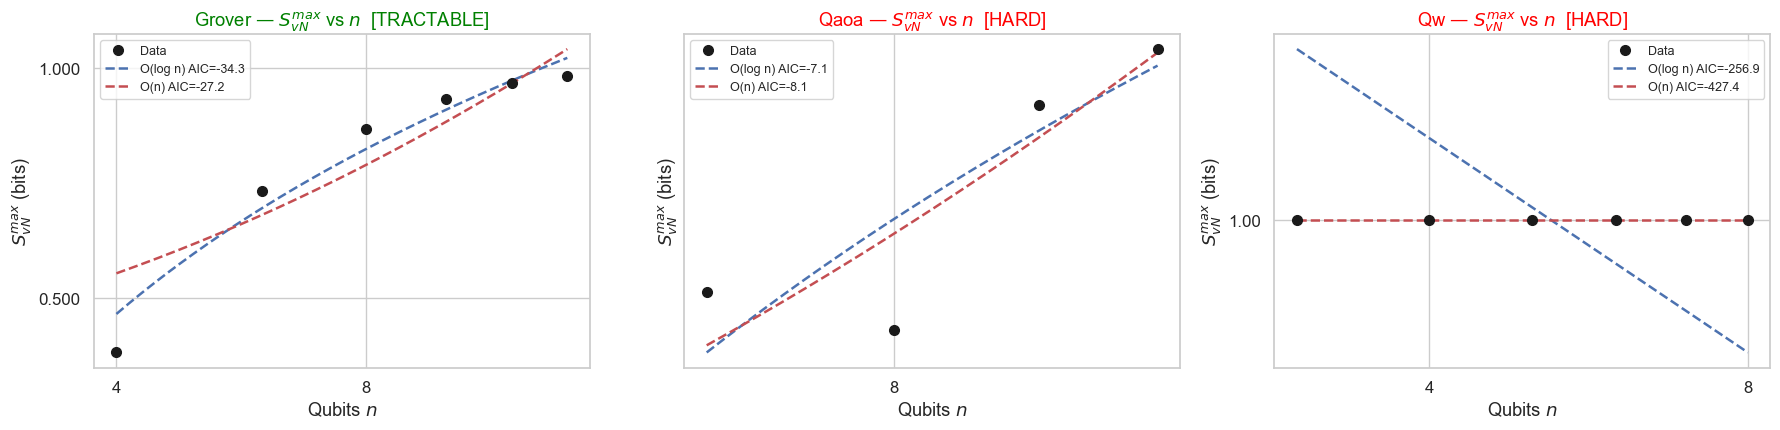

  → figures/fig2_smax_vs_n.png


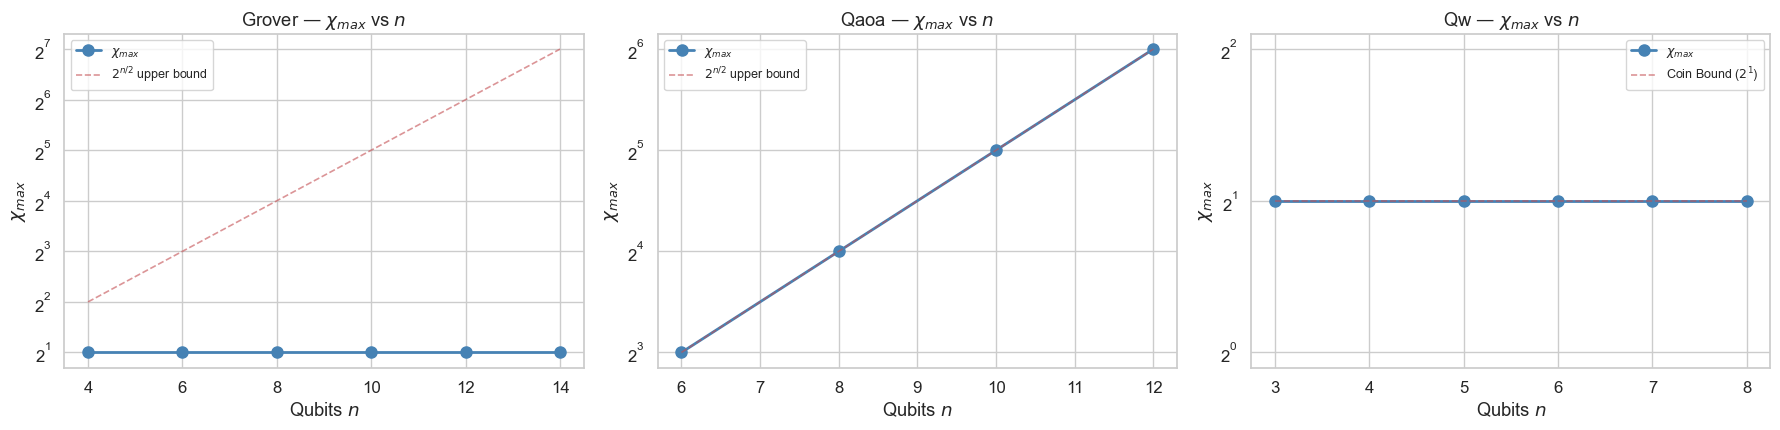

  → figures/fig3_chimax_vs_n.png


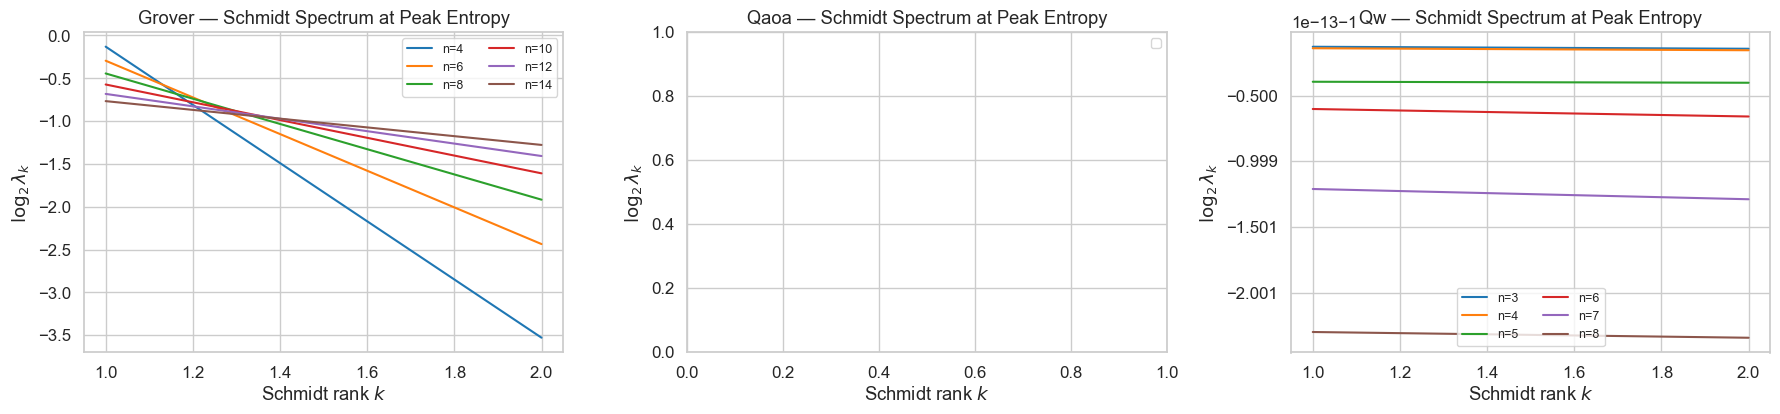

  → figures/fig4_schmidt_spectrum.png


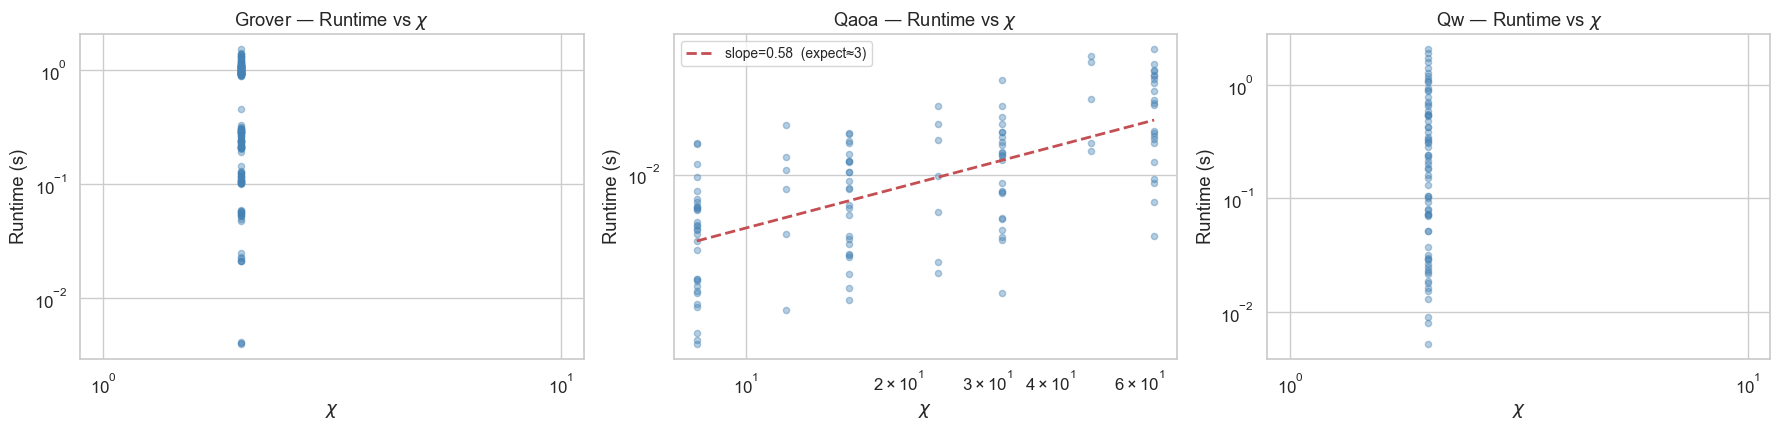

  → figures/fig5_runtime_vs_chi.png


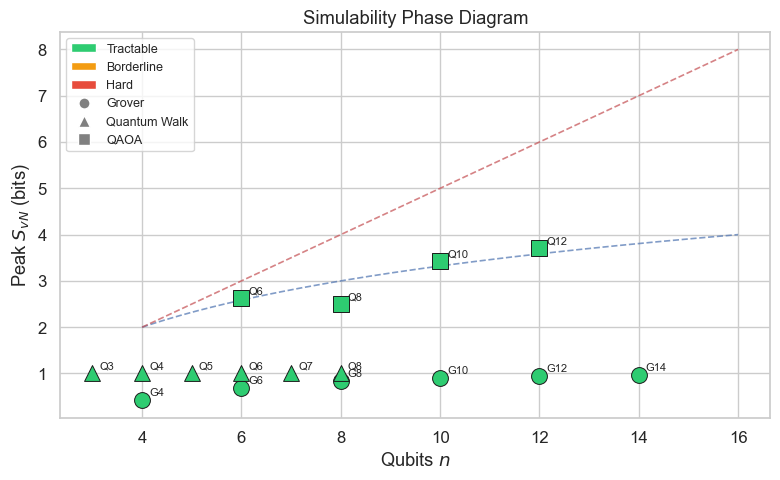

  → figures/fig6_phase_diagram.png

  SIMULABILITY CLASSIFICATION
  grover      AIC_log=-34.3  AIC_lin=-27.2  →  ✅ Tractable
  qaoa        AIC_log=-7.1  AIC_lin=-8.1  →  ❌ Hard
  qw          AIC_log=-256.9  AIC_lin=-427.4  →  ❌ Hard


In [6]:
# ── ALL-IN-ONE ANALYSIS SCRIPT FOR COLAB
import os
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
import matplotlib.patches as mp
import seaborn as sns
from scipy.linalg import svd as scipy_svd
from scipy.optimize import curve_fit

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = sns.color_palette('tab10')
os.makedirs('figures', exist_ok=True)

# 1. UTILITY & MATH FUNCTIONS


def _bipartite_matrix(statevector, n, cut):
    psi = np.asarray(statevector, dtype=complex).ravel()
    return psi.reshape(2**cut, 2**(n-cut))

def get_schmidt_spectrum(statevector, n, cut):
    sv = scipy_svd(_bipartite_matrix(statevector, n, cut), compute_uv=False)
    return np.sort(sv**2)[::-1]

def _log_model(n, a, b):    return a * np.log2(n.astype(float)) + b
def _linear_model(n, c, d): return c * n.astype(float) + d

def _aic(resid, k):
    rss = np.sum(resid**2)
    return len(resid)*np.log(rss/len(resid)) + 2*k if rss > 0 else -np.inf

def classify_simulability(ns, s_max):
    ns, s_max = np.asarray(ns, float), np.asarray(s_max, float)
    try:
        lp, _ = curve_fit(_log_model, ns, s_max, p0=[1., 0.], maxfev=10000)
        al = _aic(s_max - _log_model(ns, *lp), 2)
    except:
        lp = (np.nan, np.nan); al = np.inf
    try:
        cp, _ = curve_fit(_linear_model, ns, s_max, p0=[0.5, 0.], maxfev=10000)
        ac = _aic(s_max - _linear_model(ns, *cp), 2)
    except:
        cp = (np.nan, np.nan); ac = np.inf
    return ('tractable' if al <= ac else 'hard'), lp, cp, al, ac

# 2. PLOTTING FUNCTIONS (With Quantum Walk fully integrated)

def load():
    dfs = {}
    for name, path in [('grover','results/grover_results.csv'),
                       ('qaoa','results/qaoa_results.csv'),
                       ('qw', 'results/qw_results.csv')]:
        if os.path.isfile(path):
            dfs[name] = pd.read_csv(path)
            print(f"  {name}: {len(dfs[name])} rows loaded")
    return dfs

def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(f'figures/{name}', dpi=150, bbox_inches='tight')
    plt.show(); print(f"  → figures/{name}")

# ── Plot 1: S_vN vs step
def plot1(dfs):
    fig, axes = plt.subplots(1, len(dfs), figsize=(6*len(dfs), 4.5))
    if len(dfs)==1: axes=[axes]

    titles = {'grover': ('Grover — $S_{vN}$ vs Iteration', 'Iteration $k$'),
              'qaoa':   ('QAOA — $S_{vN}$ vs Depth $p$', 'Depth $p$'),
              'qw':     ('Quantum Walk — $S_{vN}$ vs Step $t$', 'Step $t$')}

    for ax, (algo, df) in zip(axes, dfs.items()):
        t, xl = titles[algo]
        for i, n in enumerate(sorted(df['n'].unique())):
            sub = df[df['n']==n]
            if algo == 'qaoa':
                m = sub.groupby('step')['entropy'].mean()
                s = sub.groupby('step')['entropy'].std().fillna(0)
                ax.plot(m.index, m, marker='o', ms=4, color=PALETTE[i], label=f'n={n}')
                ax.fill_between(m.index, m-s, m+s, alpha=0.15, color=PALETTE[i])
            else:
                ax.plot(sub['step'], sub['entropy'], lw=1.5, color=PALETTE[i], label=f'n={n}')

        ax.set(title=t, xlabel=xl, ylabel='$S_{vN}$ (bits)')
        ax.legend(fontsize=9, ncol=2)
    savefig(fig, 'fig1_entropy_vs_step.png')

# ── Plot 2: S_max vs n log-log
def plot2(dfs):
    fig, axes = plt.subplots(1, len(dfs), figsize=(6*len(dfs), 4.5))
    if len(dfs)==1: axes=[axes]
    for ax, (algo, df) in zip(axes, dfs.items()):
        ns = np.array(sorted(df['n'].unique()), float)
        sm = np.array([df[df['n']==n]['entropy'].max() for n in ns])

        ax.plot(ns, sm, 'ko', ms=7, zorder=5, label='Data')
        nf = np.linspace(ns.min(), ns.max(), 200)

        cls, lp, cp, al, ac = classify_simulability(ns, sm)

        if not np.isnan(lp[0]):
            ax.plot(nf, _log_model(nf,*lp), 'b--', lw=1.8, label=f'O(log n) AIC={al:.1f}')
        if not np.isnan(cp[0]):
            ax.plot(nf, _linear_model(nf,*cp), 'r--', lw=1.8, label=f'O(n) AIC={ac:.1f}')

        c = 'green' if cls=='tractable' else 'red'
        ax.set_title(f'{algo.capitalize()} — $S_{{vN}}^{{max}}$ vs $n$  [{cls.upper()}]', color=c)
        ax.set(xlabel='Qubits $n$', ylabel='$S_{vN}^{max}$ (bits)')
        ax.set_xscale('log', base=2); ax.set_yscale('log', base=2)
        ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
        ax.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
        ax.legend(fontsize=9)
    savefig(fig, 'fig2_smax_vs_n.png')

# ── Plot 3: chi_max vs n
def plot3(dfs):
    fig, axes = plt.subplots(1, len(dfs), figsize=(6*len(dfs), 4.5))
    if len(dfs)==1: axes=[axes]
    for ax, (algo, df) in zip(axes, dfs.items()):
        ns = sorted(df['n'].unique())
        cm = [df[df['n']==n]['chi'].max() for n in ns]

        ax.plot(ns, cm, 'o-', color='steelblue', ms=8, lw=2, label='$\\chi_{max}$')

        # Upper bound: For QAOA/Grover it's 2^(n/2). For QW (cut=1), it's bounded by 2^1 = 2.
        if algo == 'qw':
            ax.plot(ns, [2 for _ in ns], 'r--', lw=1.2, alpha=0.6, label='Coin Bound ($2^1$)')
        else:
            ax.plot(ns, [2**(n/2) for n in ns], 'r--', lw=1.2, alpha=0.6, label='$2^{n/2}$ upper bound')

        ax.set_yscale('log', base=2)
        ax.set(title=f'{algo.capitalize()} — $\\chi_{{max}}$ vs $n$', xlabel='Qubits $n$', ylabel='$\\chi_{max}$')
        ax.legend(fontsize=9)
    savefig(fig, 'fig3_chimax_vs_n.png')

# ── Plot 4: Schmidt spectrum
def plot4(dfs):
    fig, axes = plt.subplots(1, len(dfs), figsize=(6*len(dfs), 4.5))
    if len(dfs)==1: axes=[axes]
    for ax, (algo, df) in zip(axes, dfs.items()):
        for i, n in enumerate(sorted(df['n'].unique())):
            sub  = df[df['n']==n]
            row  = sub.loc[sub['entropy'].idxmax()]
            step = int(row['step'])
            inst = int(row.get('instance_id', 0))

            # Paths to peak statevectors
            if algo == 'grover':
                path = f'peak_states/grover_n{n}_peak.npy'
            elif algo == 'qw':
                path = f'peak_states/qw_n{n}_peak.npy'
            else:
                path = f'peak_states/qaoa_n{n}_p{step}_inst{inst}_peak.npy'

            if not os.path.isfile(path): continue

            # Identify the correct cut size (QW cut is just 1 qubit for the coin)
            cut_size = 1 if algo == 'qw' else n//2
            total_qubits = n + 1 if algo == 'qw' else n

            try:
                spec = get_schmidt_spectrum(np.load(path), total_qubits, cut_size)
                spec = spec[spec > 1e-12]
                ax.plot(range(1,len(spec)+1), np.log2(spec+1e-15), color=PALETTE[i], lw=1.5, label=f'n={n}')
            except Exception as e:
                print(f"Skipping {algo} n={n} Schmidt spectrum due to shape mismatch.")

        ax.set(title=f'{algo.capitalize()} — Schmidt Spectrum at Peak Entropy',
               xlabel='Schmidt rank $k$', ylabel='$\\log_2 \\lambda_k$')
        ax.legend(fontsize=9, ncol=2)
    savefig(fig, 'fig4_schmidt_spectrum.png')

# ── Plot 5: Runtime vs chi
def plot5(dfs):
    fig, axes = plt.subplots(1, len(dfs), figsize=(6*len(dfs), 4.5))
    if len(dfs)==1: axes=[axes]
    for ax, (algo, df) in zip(axes, dfs.items()):
        sub = df[df['chi']>1]
        ax.scatter(sub['chi'], sub['runtime_s'], alpha=0.4, s=20, color='steelblue')

        lc = np.log10(sub['chi'].values.astype(float))
        lr = np.log10(sub['runtime_s'].values.astype(float)+1e-9)
        mask = np.isfinite(lc) & np.isfinite(lr)

        # Only plot regression line if there's variance in chi
        if mask.sum() > 2 and len(np.unique(lc[mask])) > 1:
            cf = np.polyfit(lc[mask], lr[mask], 1)
            xf = np.linspace(lc[mask].min(), lc[mask].max(), 100)
            ax.plot(10**xf, 10**np.polyval(cf,xf), 'r--', lw=2, label=f'slope={cf[0]:.2f}  (expect≈3)')

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set(title=f'{algo.capitalize()} — Runtime vs $\\chi$', xlabel='$\\chi$', ylabel='Runtime (s)')
        if len(ax.get_legend_handles_labels()[1]) > 0:
            ax.legend(fontsize=10)
    savefig(fig, 'fig5_runtime_vs_chi.png')

# ── Plot 6: Phase diagram
def plot6(dfs):
    fig, ax = plt.subplots(figsize=(8,5))
    for algo, df in dfs.items():
        for n in sorted(df['n'].unique()):
            S = df[df['n']==n]['entropy'].max()

            c = '#2ECC71' if S<=np.log2(n)*1.5 else ('#E74C3C' if S>=n*0.3 else '#F39C12')

            # Map markers: Grover (circle), QAOA (square), QW (triangle)
            m = 'o' if algo=='grover' else ('s' if algo=='qaoa' else '^')

            ax.scatter(n, S, c=c, marker=m, s=130, edgecolors='k', lw=0.7, zorder=5)
            ax.annotate(f'{algo[0].upper()}{n}', (n,S), xytext=(5,3), textcoords='offset points', fontsize=8)

    ns = np.linspace(4,16,200)
    ax.plot(ns, np.log2(ns),  'b--', lw=1.2, alpha=0.7, label='$O(\\log n)$')
    ax.plot(ns, 0.5*ns,       'r--', lw=1.2, alpha=0.7, label='$O(n/2)$ boundary')

    legend = [mp.Patch(facecolor='#2ECC71',label='Tractable'),
              mp.Patch(facecolor='#F39C12',label='Borderline'),
              mp.Patch(facecolor='#E74C3C',label='Hard'),
              plt.Line2D([0],[0],marker='o',color='w',markerfacecolor='grey',ms=8,label='Grover'),
              plt.Line2D([0],[0],marker='^',color='w',markerfacecolor='grey',ms=8,label='Quantum Walk'),
              plt.Line2D([0],[0],marker='s',color='w',markerfacecolor='grey',ms=8,label='QAOA')]

    ax.legend(handles=legend, fontsize=9)
    ax.set(title='Simulability Phase Diagram', xlabel='Qubits $n$', ylabel='Peak $S_{vN}$ (bits)')
    savefig(fig, 'fig6_phase_diagram.png')

# ── Classification table
def classification_table(dfs):
    print("\n" + "="*60)
    print("  SIMULABILITY CLASSIFICATION")
    print("="*60)
    for algo, df in dfs.items():
        ns  = np.array(sorted(df['n'].unique()), float)
        sm  = np.array([df[df['n']==n]['entropy'].max() for n in ns])

        # Don't try to classify if we have less than 3 data points
        if len(ns) < 3:
            print(f"  {algo:<10}  Not enough data points to classify.")
            continue

        cls, _, _, al, ac = classify_simulability(ns, sm)
        v = '✅ Tractable' if cls=='tractable' else '❌ Hard'
        print(f"  {algo:<10}  AIC_log={al:.1f}  AIC_lin={ac:.1f}  →  {v}")
    print("="*60)

# 3. RUN ALL PLOTS
dfs = load()
if dfs:
    plot1(dfs)
    plot2(dfs)
    plot3(dfs)
    plot4(dfs)
    plot5(dfs)
    plot6(dfs)
    classification_table(dfs)
else:
    print("No CSV files found in the 'results/' directory. Please run the simulation scripts first!")